In [1]:
import os
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torch.utils.data import random_split
import torch

torch.manual_seed(42)

class MVTecDataset(Dataset):
    def __init__(self, root, category, split="train", transform=None, mask_transform=None):
        """
        root      : path to MVTec root folder
        category  : e.g. "Leather"
        split     : "train" or "test"
        transform : torchvision transforms
        mask_transform : transforms for masks (if needed)
        """

        self.transform = transform
        self.mask_transform = mask_transform
        self.samples = []

        if split == "train":
            good_dir = Path(root) / category / "train" / "good"
            for img_path in sorted(good_dir.glob("*.png")):
                self.samples.append((img_path, None, 0)) 

        elif split == "test":
            test_dir = Path(root) / category / "test"
            gt_dir = Path(root) / category / "ground_truth"
            for defect_type in sorted(test_dir.iterdir()):
                if defect_type.is_dir():
                    label = 0 if defect_type.name == "good" else 1
                    for img_path in sorted(defect_type.glob("*.png")):
                        mask_path = None if label == 0 else gt_dir / defect_type.name / (img_path.stem + "_mask.png")
                        self.samples.append((img_path, mask_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        if mask_path is not None:
            mask = Image.open(mask_path).convert("L")
            if self.mask_transform:
                mask = self.mask_transform(mask)
        else:
            mask = torch.zeros(1,256,256)

        return image, mask, label


IMG_SIZE = 256

transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

mask_transform = T.Compose([
    T.Resize((256,256), interpolation=T.InterpolationMode.NEAREST),
    T.ToTensor()
])

MVTEC_ROOT = "./dataset"
CATEGORY = "leather"



train_dataset = MVTecDataset(MVTEC_ROOT, CATEGORY, split="train", transform=transform, mask_transform=mask_transform)
val_len = int(0.2 * len(train_dataset))
train_len = len(train_dataset) - val_len
train_dataset, val_dataset = random_split(train_dataset, [train_len, val_len]) 
test_dataset = MVTecDataset(MVTEC_ROOT, CATEGORY, split="test", transform=transform, mask_transform=mask_transform)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Train samples: 196
Test samples: 124


In [2]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
defect_val_len = int(0.2 * len(test_dataset))
test_len = len(test_dataset) - defect_val_len
defect_val_dataset, split_test_dataset = random_split(test_dataset, [defect_val_len, test_len])

defect_val_loader = DataLoader(defect_val_dataset, batch_size=1, shuffle=True)
split_test_loader = DataLoader(split_test_dataset, batch_size=1, shuffle=True)

images, _, labels = next(iter(train_loader))
print(images.shape)
print(labels)

torch.Size([8, 3, 256, 256])
tensor([0, 0, 0, 0, 0, 0, 0, 0])


In [3]:
from torchvision.models import resnet18
from torch import nn

model = resnet18(weights='IMAGENET1K_V1')

feature_extractor = nn.Sequential(
    model.conv1,
    model.bn1,
    model.relu,
    model.maxpool,
    model.layer1,
    model.layer2
)

In [6]:

BASE_MODEL_PATH = 'models/'
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def build_memory_bank(extractor, train_loader, device):
    extractor.eval()
    patch_list=[]
    with torch.no_grad():
        for images, _, _ in train_loader:
            images = images.to(device)

            features = extractor(images)
            B, C, H, W = features.shape

            patches = features.permute(0,2,3,1).reshape(-1,C)
            patch_list.append(patches.cpu())

    memory_bank = torch.cat(patch_list, dim=0)

    print(f"Memory Bank shape: {memory_bank.shape}")
    return memory_bank

feature_extractor = feature_extractor.to(DEVICE)
memory_bank = build_memory_bank(feature_extractor, train_loader, DEVICE)

Memory Bank shape: torch.Size([200704, 128])


In [ ]:
def coreset_subsample(memory_bank, ratio = 0.1, seed=42):
    torch.manual_seed(seed)
    N = memory_bank.shape[0]
    n_select = max(1, int(N * ratio))

    selected_indices = [torch.randint(0, N, (1,)).item()]

    min_distances = torch.full((N,), float("inf"))

    for i in range(n_select - 1):
        if i%1000==0 or i == 1:
            print(f"Sample {i} of {n_select}")
        last = memory_bank[selected_indices[-1]].unsqueeze(0)
        dists = torch.cdist(memory_bank, last).squeeze(1)

        min_distances = torch.minimum(min_distances, dists)

        selected_indices.append(min_distances.argmax().item())

    coreset = memory_bank[selected_indices]
    print(f"Coreset shape: {coreset.shape}")

    return coreset

coreset = coreset_subsample(memory_bank, ratio = 0.1)

print(f"Full Memory Bank: {memory_bank.shape}")
print(f"Coreset: {coreset.shape}")
print(f"Feature Range: {coreset.min():.3f} to {coreset.max():.3f}")
SAVE_PATH = f"{BASE_MODEL_PATH}/coreset_{CATEGORY}.pth"

torch.save(coreset, SAVE_PATH)

Sample 0 of 20070
Sample 1 of 20070
Sample 1000 of 20070
Sample 2000 of 20070
Sample 3000 of 20070
Sample 4000 of 20070
Sample 5000 of 20070
Sample 6000 of 20070
Sample 7000 of 20070
Sample 8000 of 20070
Sample 9000 of 20070
Sample 10000 of 20070
Sample 11000 of 20070
Sample 12000 of 20070
Sample 13000 of 20070
Sample 14000 of 20070
Sample 15000 of 20070
Sample 16000 of 20070
Sample 17000 of 20070
Sample 18000 of 20070
Sample 19000 of 20070
Sample 20000 of 20070
Coreset shape: torch.Size([20070, 128])
Full Memory Bank: torch.Size([200704, 128])
Coreset: torch.Size([20070, 128])
Feature Range: 0.000 to 3.644


In [4]:
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
import numpy as np



BASE_MODEL_PATH = 'models/'
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_PATH = f"{BASE_MODEL_PATH}/coreset_{CATEGORY}.pth"

coreset = torch.load(SAVE_PATH, map_location=DEVICE)


def inference(extractor, coreset, image_tensor, device):
    extractor.eval()
    coreset = coreset.to(device)

    with torch.no_grad():
        features = extractor(image_tensor.to(device))

        B, C, H, W = features.shape

        patches = features.permute(0,2,3,1).reshape(-1,C)

        dists = torch.cdist(patches, coreset)
        nn_dists = dists.min(dim=1).values
        anomaly_map = nn_dists.reshape(H,W).cpu()

        score = anomaly_map.max().item()

        anomaly_map = F.interpolate(
            anomaly_map.unsqueeze(0).unsqueeze(0),
            size=(256,256),
            mode = "bilinear",
            align_corners = False
        ).squeeze().numpy()

    return anomaly_map, score


def evaluate(extractor, coreset, loader, device):

    image_scores = []
    image_labels = []

    pixel_scores = []
    pixel_labels = []

    for images, masks, labels in loader:
        
        anomaly_map, score = inference(extractor, coreset, images, device)

        image_scores.append(score)
        image_labels.append(labels.item())

        pixel_scores.append(anomaly_map.ravel())
        pixel_labels.append(masks.squeeze().numpy().ravel())

    image_auroc = roc_auc_score(image_labels, image_scores)


    all_pixel_scores = np.concatenate(pixel_scores)
    all_pixel_labels = np.concatenate(pixel_labels)
    pixel_auroc = roc_auc_score(all_pixel_labels, all_pixel_scores)

    return image_auroc, pixel_auroc


image_auroc, pixel_auroc = evaluate(extractor=feature_extractor, coreset=coreset, loader = defect_val_loader, device=DEVICE)

print(f"Image AUROC: {image_auroc:.4f}")
print(f"Pixel AUROC: {pixel_auroc:.4f}")


Image AUROC: 1.0000
Pixel AUROC: 0.9929


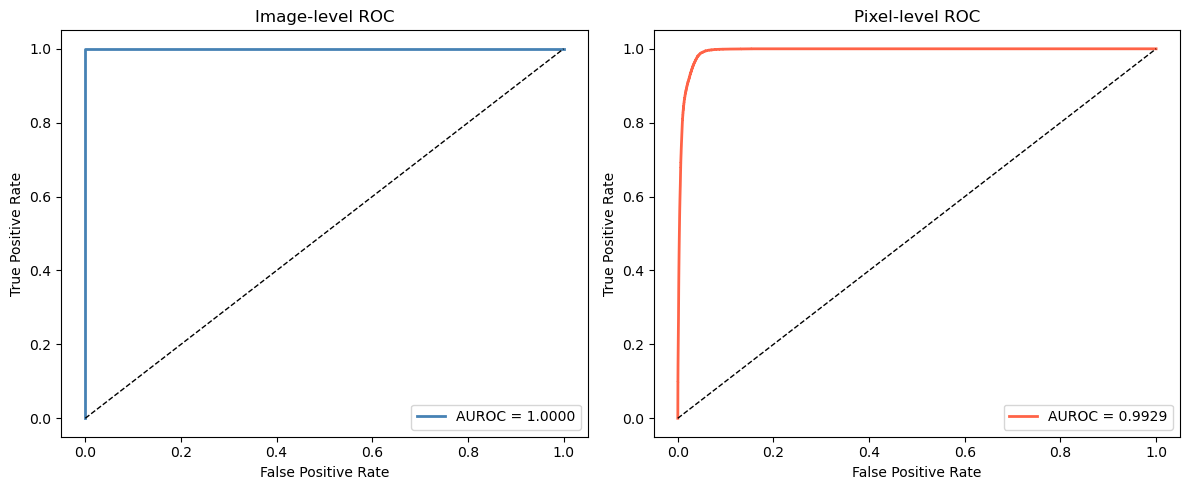

In [5]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

def plot_roc_curves(extractor, coreset, loader, device):
    image_scores, image_labels = [], []
    pixel_scores, pixel_labels = [], []

    for images, masks, labels in loader:
        
        anomaly_map, score = inference(extractor, coreset, images, device)

        image_scores.append(score)
        image_labels.append(labels.item())

        pixel_scores.append(anomaly_map.ravel())
        pixel_labels.append(masks.squeeze().numpy().ravel())

    img_fpr, img_tpr, _ = roc_curve(image_labels, image_scores)
    img_auc = roc_auc_score(image_labels, image_scores)


    pix_fpr, pix_tpr, _ = roc_curve(
        np.concatenate(pixel_labels),
        np.concatenate(pixel_scores)
    )
    pix_auc = roc_auc_score(np.concatenate(pixel_labels), np.concatenate(pixel_scores))

    fig, axes = plt.subplots(1, 2, figsize=(12,5))

    axes[0].plot(img_fpr, img_tpr, color="steelblue", lw=2, label=f"AUROC = {img_auc:.4f}")
    axes[0].plot([0,1], [0,1], "k--", lw=1)
    axes[0].set_title("Image-level ROC")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].legend()

    axes[1].plot(pix_fpr, pix_tpr, color="tomato", lw=2, label=f"AUROC = {pix_auc:.4f}")
    axes[1].plot([0,1], [0,1], "k--", lw=1)
    axes[1].set_title("Pixel-level ROC")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_roc_curves(feature_extractor, coreset, defect_val_loader, DEVICE)

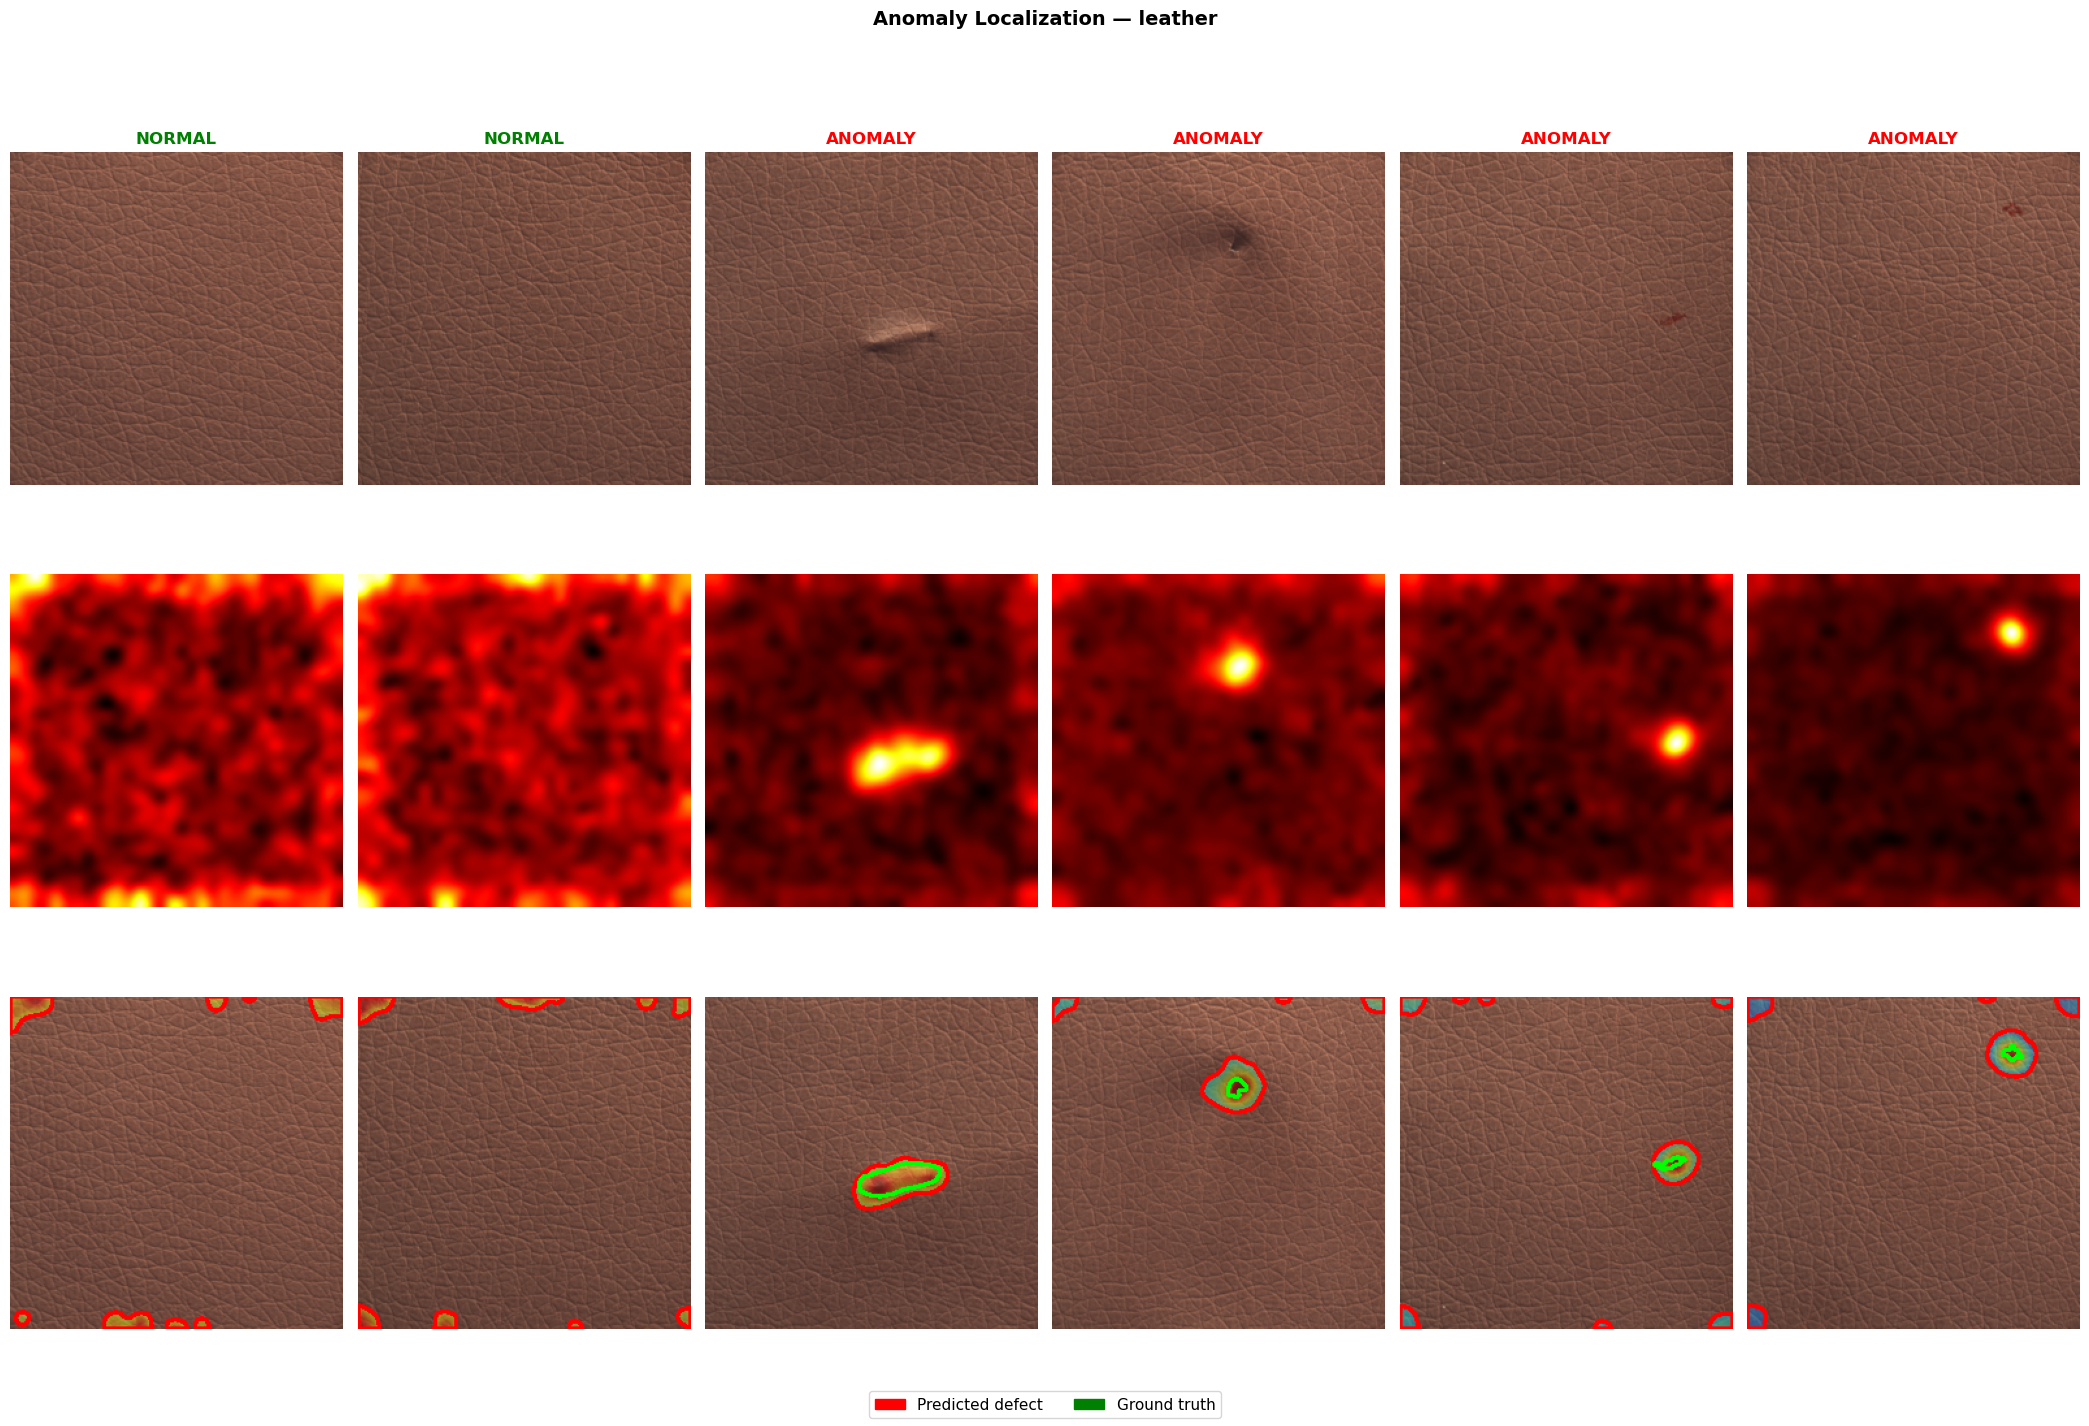

In [6]:
from scipy.ndimage import gaussian_filter
import cv2

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (tensor.cpu() * std + mean).clamp(0, 1)


def get_anomaly_overlay(original_np, error_map, blur_sigma=4, threshold_percentile=97, alpha=0.4):
    """
    original_np : numpy [H, W, 3] in range [0, 1]
    error_map   : numpy [H, W]    raw per-pixel MSE
    Returns     : overlaid image [H, W, 3]
    """
    # 1. Smooth
    smoothed = gaussian_filter(error_map, sigma=blur_sigma)

    # 2. Normalize to [0, 1]
    smoothed = (smoothed - smoothed.min()) / (smoothed.max() - smoothed.min() + 1e-8)

    # 3. Threshold
    threshold = np.percentile(smoothed, threshold_percentile)
    binary_mask = (smoothed > threshold).astype(np.uint8)

    # 4. Morphological cleanup
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN,  kernel)
    #binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)

    # 5. Colored heatmap (jet colormap over smoothed map)
    heatmap = plt.cm.jet(smoothed)[:, :, :3]   # [H, W, 3], drop alpha channel

    # 6. Blend heatmap only where mask is active
    overlay = original_np.copy()
    mask_bool = binary_mask.astype(bool)          # [H, W]
    overlay[mask_bool] = (
        (1 - alpha) * original_np[mask_bool] +
        alpha       * heatmap[mask_bool]
    )

    # 7. Draw contour around detected region
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    overlay_uint8 = (overlay * 255).astype(np.uint8)
    cv2.drawContours(overlay_uint8, contours, -1, (255, 0, 0), 2)   # red contour

    return overlay_uint8, smoothed, binary_mask



def visualize_localization(extractor, coreset, loader, device, n_normal=2, n_anomaly=4):
    extractor.eval()

    normal_samples  = []
    anomaly_samples = []

    for images, masks, labels in loader:
        item = (images, masks, labels.item())
        if labels.item() == 0 and len(normal_samples)  < n_normal:
            normal_samples.append(item)
        if labels.item() == 1 and len(anomaly_samples) < n_anomaly:
            anomaly_samples.append(item)
        if len(normal_samples) == n_normal and len(anomaly_samples) == n_anomaly:
            break

    all_samples = normal_samples + anomaly_samples
    n_cols = len(all_samples)
    fig, axes = plt.subplots(3, n_cols, figsize=(3.5 * n_cols, 14))

    row_labels = ["Original", "Anomaly map", "Localization"]
    for ax, label in zip(axes[:, 0], row_labels):
        ax.set_ylabel(label, fontsize=12, fontweight="bold")

    for col, (images, masks, label) in enumerate(all_samples):
        anomaly_map, score = inference(extractor, coreset, images, device)

        orig_np  = denormalize(images[0].cpu()).permute(1,2,0).numpy()
        overlay, smoothed, mask = get_anomaly_overlay(orig_np, anomaly_map)


        title_color = "green" if label == 0 else "red"
        title_text  = "NORMAL" if label == 0 else "ANOMALY"

        # Row 0: original
        axes[0, col].imshow(orig_np)
        axes[0, col].set_title(title_text, color=title_color, fontweight="bold")
        axes[0, col].axis("off")

        # Row 1: smoothed error map
        axes[1, col].imshow(smoothed, cmap="hot")
        axes[1, col].axis("off")

        # Row 2: overlay with contour
        axes[2, col].imshow(overlay)
        # Ground truth mask contour in green if available
        gt_mask = masks.squeeze().numpy()
        if gt_mask.max() > 0:
            gt_contours, _ = cv2.findContours(
                (gt_mask * 255).astype(np.uint8),
                cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
            )
            overlay_copy = overlay.copy()
            cv2.drawContours(overlay_copy, gt_contours, -1, (0, 255, 0), 2)  # green = GT
            axes[2, col].imshow(overlay_copy)
        axes[2, col].axis("off")

    # Legend
    from matplotlib.patches import Patch
    legend = [Patch(color="red",   label="Predicted defect"),
              Patch(color="green", label="Ground truth")]
    fig.legend(handles=legend, loc="lower center", ncol=2, fontsize=11, frameon=True)

    plt.suptitle(f"Anomaly Localization — {CATEGORY}", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


visualize_localization(feature_extractor, coreset, defect_val_loader, DEVICE)

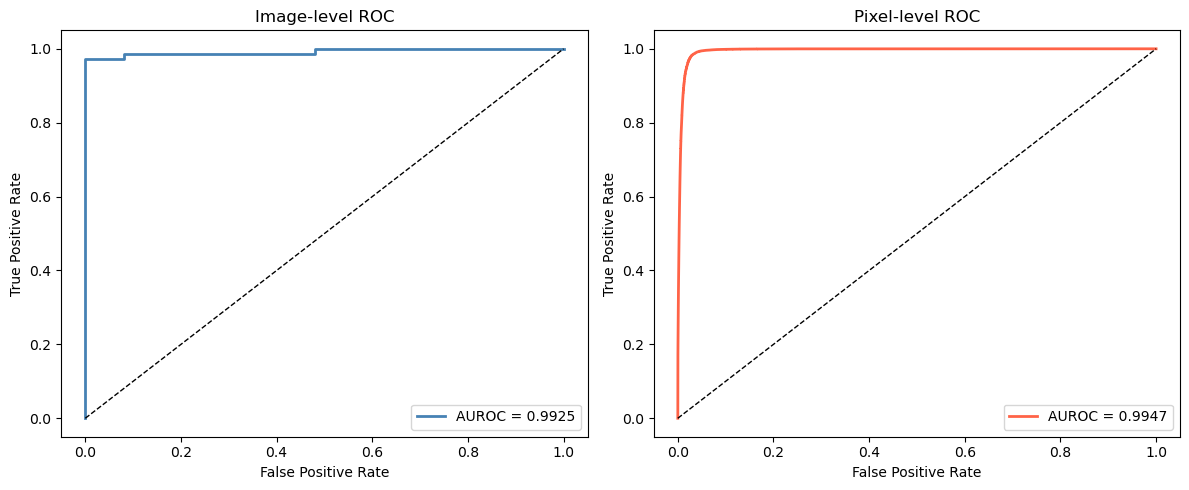

In [7]:
plot_roc_curves(feature_extractor, coreset, split_test_loader, DEVICE)

In [8]:
def find_optimal_threshold(labels, scores):
    fpr, tpr, thresholds = roc_curve(labels, scores)
    youden_idx = np.argmax(tpr-fpr)
    threshold = thresholds[youden_idx]

    return threshold




image_scores, image_labels = [], []
pixel_scores, pixel_labels = [], []

for images, masks, labels in split_test_loader:
    
    anomaly_map, score = inference(feature_extractor, coreset, images, DEVICE)

    image_scores.append(score)
    image_labels.append(labels.item())

    pixel_scores.append(anomaly_map.ravel())
    pixel_labels.append(masks.squeeze().numpy().ravel())


image_threshold = find_optimal_threshold(image_labels, image_scores)
pixel_threshold = find_optimal_threshold(np.concatenate(pixel_labels), np.concatenate(pixel_scores))

print(f"Optimal Image threshold: {image_threshold:.3f}")
print(f"Optimal Pixel threshold: {pixel_threshold:.3f}")

Optimal Image threshold: 2.471
Optimal Pixel threshold: 1.793
